# 1 · Benchmark data, noise and baselines

This notebook is the first part of the **autoresearch equation-discovery** toolkit (`eqdisc`). We

1. generate ODE/PDE datasets with known ground truth, a **public** noisy training set and a **hidden** clean test set
   from unseen initial conditions;
2. look at different noise models (white, multiplicative, red/correlated, outliers);
3. run classic **SINDy** (and optionally PySR) baselines;
4. score models with the **hidden evaluator**: vector-field error, rollout error, valid time and parsimony.

The agent and evolution loops (notebooks 2–3) are built on exactly these pieces.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display, Markdown, Math
import sympy as sp
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
from eqdisc import toolbox as tb, coordinates as co, plots, solvers
from eqdisc.evaluate import evaluate, load
from eqdisc.datagen import generate, add_noise, simulate, NOISE_TYPES
from eqdisc.systems import SYSTEMS

def show_eqs(rhs, title=None):
    """Pretty-print a model {var: expr} as LaTeX."""
    if title: display(Markdown(f"**{title}**"))
    for v, e in rhs.items():
        names = list(rhs) + ["t", "x"] + [f"{v}_{'x'*k}" for k in range(1, 5)]
        expr = solvers.parse(e, names) if isinstance(e, str) else e
        expr = expr.xreplace({a: sp.Float(float(a), 3) for a in expr.atoms(sp.Float)})
        display(Math(rf"\dot{{{sp.latex(sp.Symbol(v))}}} = {sp.latex(expr)}"))

def scorecard(dataset, rhs, label=""):
    r = evaluate(dataset, {"rhs": rhs}, reveal=True)
    return {"model": label, "score": round(r["score"], 2), "vf_nrmse": f"{r['vf_nrmse']:.2e}",
            "rollout_nrmse": f"{r['rollout_nrmse']:.2e}", "terms": r["n_terms"], "F1": round(r["f1"], 2),
            "coef_err": None if r["coef_rel_err"] is None else round(r["coef_rel_err"], 3)}

## 1.1 The system registry
Every system is a set of sympy strings, so ground truth and candidate models are integrated by the *same* solver.

In [2]:
rows = []
for name, s in SYSTEMS.items():
    rows.append({"system": name, "type": s.kind, "tags": ", ".join(s.tags),
                 "equations": "; ".join(f"d{v}/dt = {e}" for v, e in s.rhs.items())})
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows)

,system,type,tags,equations
0,lorenz,ode,"chaotic, polynomial",dx/dt = 10*(y - x); dy/dt = x*(28 - z) - y; dz/dt = x*y - 8/3*z
1,rossler,ode,"chaotic, polynomial",dx/dt = -y - z; dy/dt = x + 0.2*y; dz/dt = 0.2 + z*(x - 5.7)
2,vanderpol,ode,"limit-cycle, polynomial",dx/dt = y; dy/dt = 2*(1 - x**2)*y - x
3,duffing,ode,"damped, polynomial",dx/dt = y; dy/dt = -0.2*y + x - x**3
4,lotka_volterra,ode,"ecology, polynomial",dx/dt = 1.1*x - 0.4*x*y; dy/dt = -0.4*y + 0.1*x*y
5,hopf,ode,"limit-cycle, polynomial",dx/dt = 0.5*x - y - x*(x**2 + y**2); dy/dt = x + 0.5*y - y*(x**2 + y**2)
6,pendulum,ode,non-polynomial,dtheta/dt = omega; domega/dt = -9.81*sin(theta) - 0.1*omega
7,michaelis_menten,ode,rational,ds/dt = 0.6 - 1.5*s/(0.3 + s)
8,sir,ode,"epidemic, polynomial, conserved",dS/dt = -0.5*S*I; dI/dt = 0.5*S*I - 0.1*I; dR/dt = 0.1*I
9,strogatz_bacterial_respiration,ode,"strogatz, rational, limit-cycle",dx/dt = 20 - x - x*y/(1 + 0.5*x**2); dy/dt = 10 - x*y/(1 + 0.5*x**2)


## 1.2 Generate a dataset
Lorenz at 1% noise: 4 training trajectories (public) and 4 test trajectories from new ICs (hidden).

{
 "name": "lorenz_n0.01_dt1_s0",
 "kind": "ode",
 "variables": [
  "x",
  "y",
  "z"
 ],
 "dt": 0.01,
 "shape": [
  4,
  1001,
  3
 ],
 "allowed_symbols": [
  "x",
  "y",
  "z",
  "t"
 ]
}


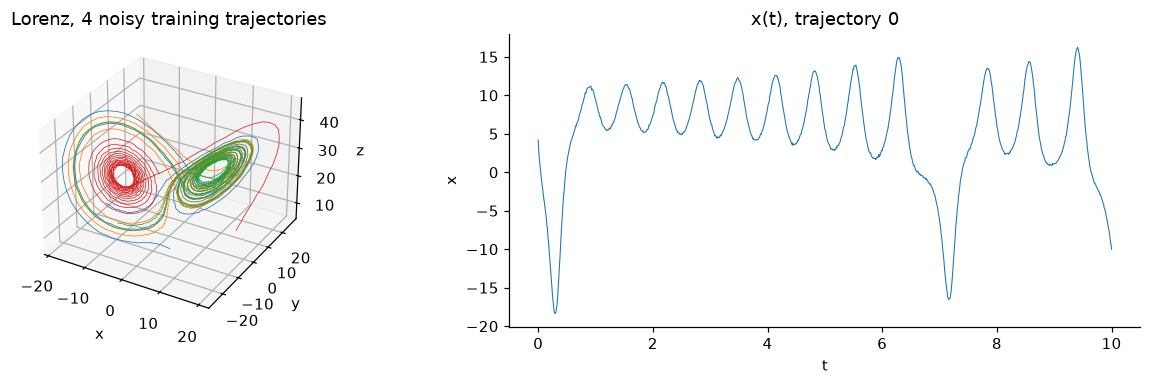

In [3]:
d_lorenz = generate("lorenz", noise=0.01, plot=False)
meta, data = load(d_lorenz)
print(json.dumps({k: meta[k] for k in ["name", "kind", "variables", "dt", "shape", "allowed_symbols"]}, indent=1))
U = data["U"]
fig = plt.figure(figsize=(12, 3.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for j in range(U.shape[0]):
    ax.plot(*U[j].T, lw=0.5)
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Lorenz, 4 noisy training trajectories")
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(data["t"], U[0, :, 0], lw=0.7); ax2.set(xlabel="t", ylabel="x", title="x(t), trajectory 0")
plt.tight_layout(); plt.show()

## 1.3 Noise models
Real data rarely has white noise. `--noise-type` controls the noise: red noise (correlated in time, AR(1)) is the nastiest for derivative-based methods because smoothing cannot remove it.

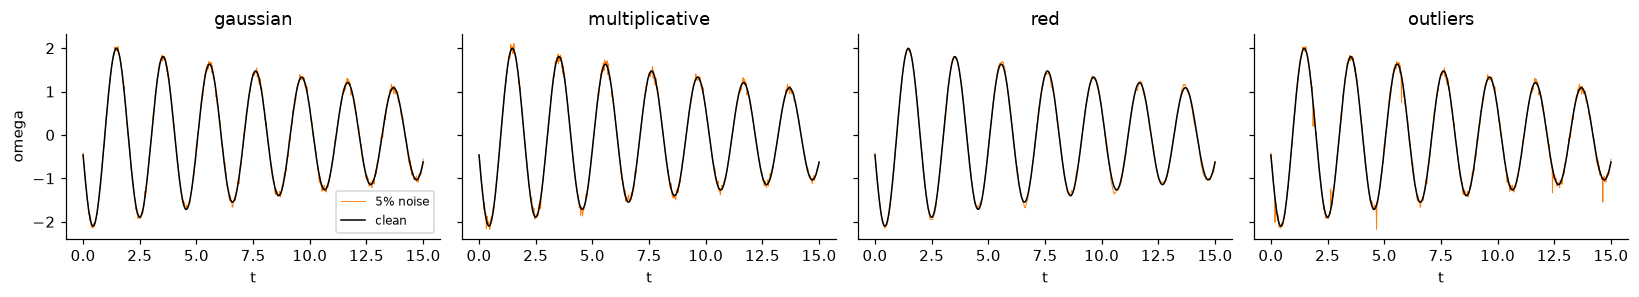

In [4]:
s = SYSTEMS["pendulum"]
rng = np.random.default_rng(0)
t, Uc = simulate(s, 1, rng)
fig, axes = plt.subplots(1, 4, figsize=(15, 2.8), sharey=True)
for ax, kind in zip(axes, NOISE_TYPES):
    Un = add_noise(Uc, 0.05, np.random.default_rng(1), kind)
    ax.plot(t, Un[0, :, 1], color="C1", lw=0.6, label="5% noise")
    ax.plot(t, Uc[0, :, 1], "k", lw=1, label="clean")
    ax.set_title(kind); ax.set_xlabel("t")
axes[0].set_ylabel("omega"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 1.4 SINDy baseline and the hidden evaluator
`toolbox.run_sindy` = Savitzky–Golay derivatives + polynomial library + STLSQ with the threshold chosen on a held-out *public* trajectory.

In [5]:
res = tb.run_sindy(meta, data, poly_degree=2)
show_eqs(res["rhs"], "SINDy on Lorenz (1% noise)")
show_eqs(SYSTEMS["lorenz"].rhs, "Ground truth")
pd.DataFrame([scorecard(d_lorenz, res["rhs"], "SINDy"), scorecard(d_lorenz, SYSTEMS["lorenz"].rhs, "truth")])

**SINDy on Lorenz (1% noise)**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Ground truth**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,SINDy,2.68,1.17e-03,1.14e-02,13,0.7,0.004
1,truth,6.36,0.00e+00,3.79e-11,7,1.0,0.000


The sparsity path shows what the threshold sweep saw (validation error vs. number of terms); the elbow is the model.

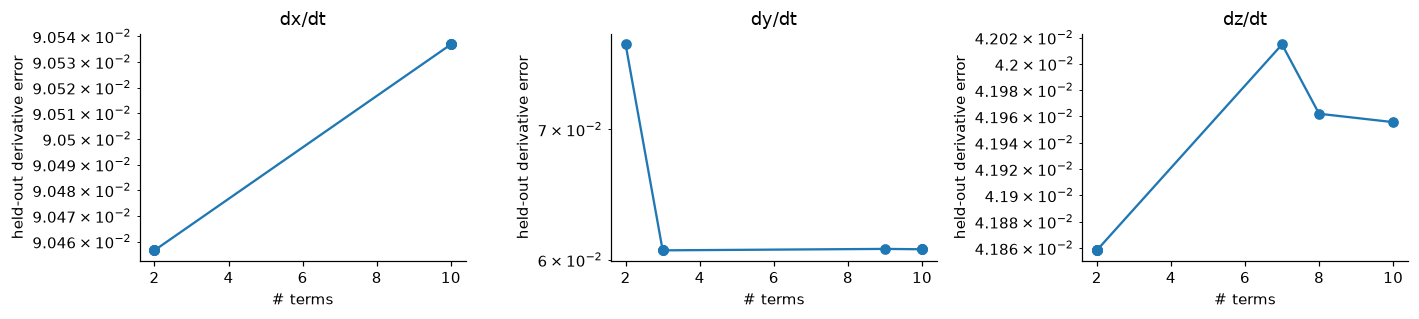

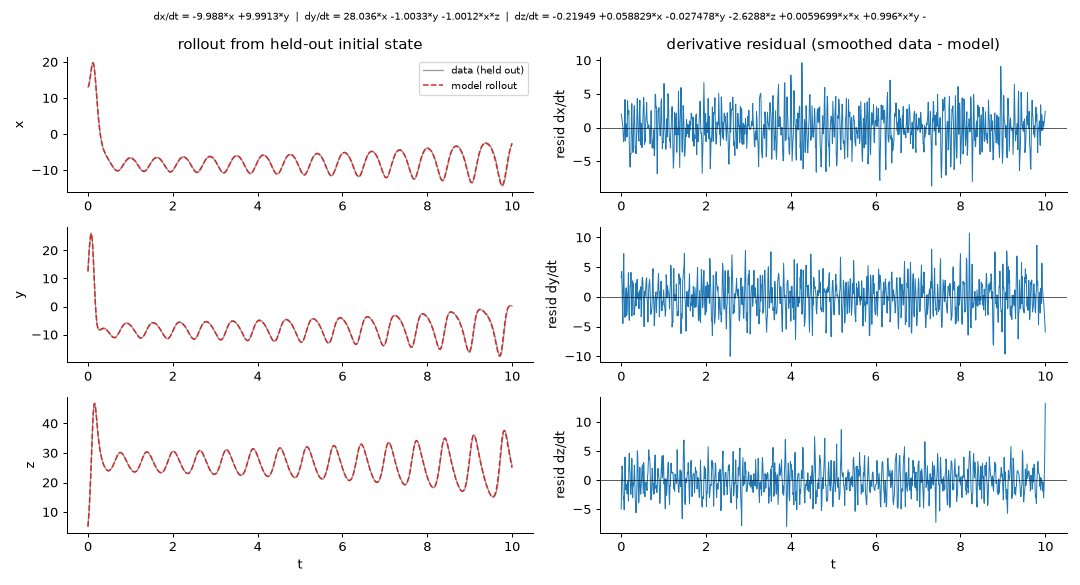

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (v, path) in zip(axes, res["sparsity_path"].items()):
    ax.plot([p["n_terms"] for p in path], [p["val_err"] for p in path], "o-")
    ax.set(xlabel="# terms", ylabel="held-out derivative error", title=f"d{v}/dt", yscale="log")
plt.tight_layout(); plt.show()
plots.plot_model(meta, data, res["rhs"], "/tmp/_m.png")
from IPython.display import Image; display(Image("/tmp/_m.png"))

## 1.5 A PDE: Korteweg–de Vries
Two solitons on a periodic domain. The same toolbox handles PDEs; library terms are monomials in `u` times one spatial derivative.

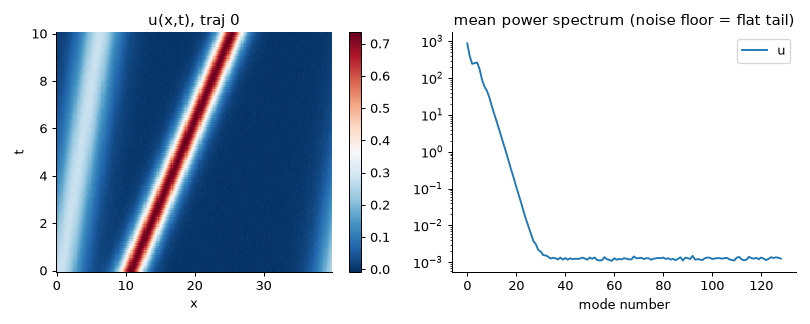

**SINDy (restricted library)**

<IPython.core.display.Math object>

**Ground truth**

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,SINDy,1.27,9.27e-02,1.92e-01,3,0.8,0.176
1,truth,6.46,0.00e+00,0.00e+00,2,1.0,0.000


In [7]:
d_kdv = generate("kdv", noise=0.01, plot=False)
mk, dk = load(d_kdv)
plots.plot_data(mk, dk, "/tmp/_k.png"); display(Image("/tmp/_k.png"))
rk = tb.run_sindy(mk, dk, poly_degree=1, max_deriv=3)
show_eqs(rk["rhs"], "SINDy (restricted library)"); show_eqs(SYSTEMS["kdv"].rhs, "Ground truth")
pd.DataFrame([scorecard(d_kdv, rk["rhs"], "SINDy"), scorecard(d_kdv, SYSTEMS["kdv"].rhs, "truth")])

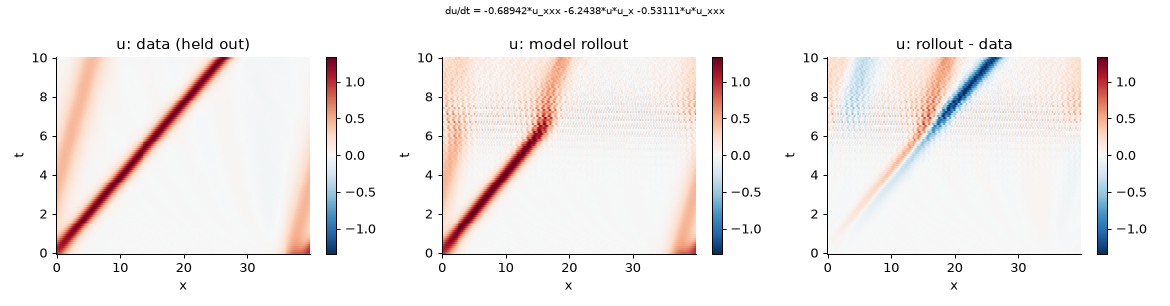

In [8]:
plots.plot_model(mk, dk, rk["rhs"], "/tmp/_km.png"); display(Image("/tmp/_km.png"))

## 1.6 Baseline scoreboard across the benchmark
Default SINDy on every system at 1% noise. Low scores mark where structure discovery (notebook 2) and the agent (notebook 3) must do better: non-polynomial terms (pendulum, Michaelis–Menten), collinear libraries (SIR), noisy high-order derivatives (KdV, KS), multi-field PDEs.

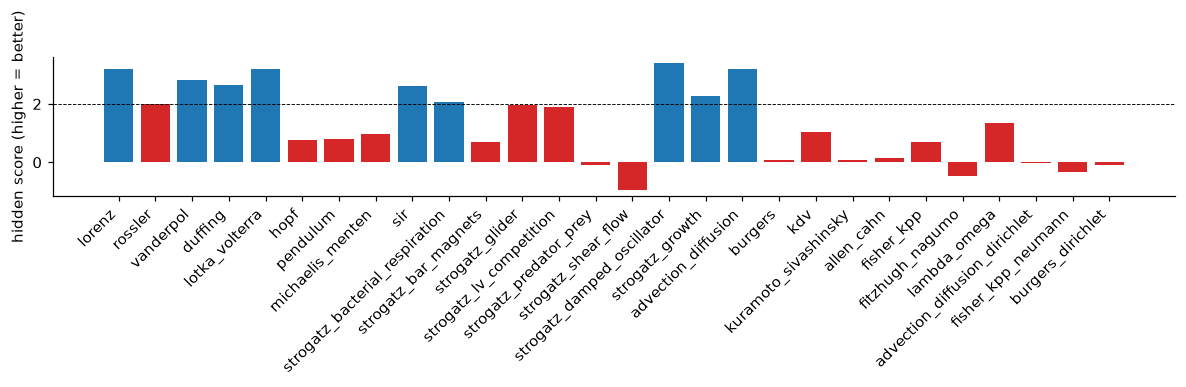

,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
system,,,,,,
lorenz,3.19,8.38e-04,2.61e-03,7,1.00,0.001
rossler,1.99,4.93e-03,4.02e-02,18,0.56,0.022
vanderpol,2.83,6.51e-04,2.38e-02,4,1.00,0.001
duffing,2.64,1.15e-03,3.13e-02,4,1.00,0.003
lotka_volterra,3.19,7.74e-04,3.69e-03,4,1.00,0.001
hopf,0.78,1.54e-01,2.05e-01,5,0.77,0.012
pendulum,0.81,1.91e-02,1.38e+00,3,0.33,0.000
michaelis_menten,0.97,5.46e-01,1.47e-01,4,0.33,0.407
sir,2.63,6.72e-03,2.75e-03,12,0.25,0.100


In [9]:
rows = []
for name in SYSTEMS:
    d = generate(name, noise=0.01, plot=False)
    m_, d_ = load(d)
    r = tb.run_sindy(m_, d_)
    rows.append({"system": name, **{k: v for k, v in scorecard(d, r["rhs"], "SINDy").items() if k != "model"}})
board = pd.DataFrame(rows).set_index("system")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(board.index, board["score"], color=["C0" if s > 2 else "C3" for s in board["score"]])
ax.axhline(2, color="k", lw=0.6, ls="--"); ax.set_ylabel("hidden score (higher = better)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
board

## 1.7 Weak-form SINDy: the fix for noisy PDEs
Differentiating noisy data is what breaks SINDy on PDEs. Weak SINDy integrates the equation against smooth test functions and moves every derivative onto them, so the data is never differentiated.

In [10]:
from eqdisc.weakform import weak_sindy
rows, models = [], {}
for name, noise, dtm in [("kdv", 0.05, 2), ("kuramoto_sivashinsky", 0.05, 1), ("burgers", 0.05, 1), ("lorenz", 0.05, 1)]:
    d = generate(name, noise=noise, dt_mult=dtm, plot=False); m_, d_ = load(d)
    s_ = tb.run_sindy(m_, d_); w_ = weak_sindy(m_, d_); models[name] = (d, m_, d_, w_)
    for lab, r in [("SINDy", s_), ("weak SINDy", w_)]:
        rows.append({"system": f"{name} ({int(noise*100)}% noise)", **scorecard(d, r["rhs"], lab)})
display(pd.DataFrame(rows))
for name in ["kdv", "kuramoto_sivashinsky"]:
    show_eqs(models[name][3]["rhs"], f"weak SINDy on {name} (5% noise)")

,system,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,kdv (5% noise),SINDy,0.45,1.67e-01,8.45e-01,4,0.33,0.790
1,kdv (5% noise),weak SINDy,3.01,1.07e-03,7.51e-03,2,1.00,0.001
2,kuramoto_sivashinsky (5% noise),SINDy,0.52,7.87e-01,4.04e-01,5,0.75,0.252
3,kuramoto_sivashinsky (5% noise),weak SINDy,2.97,3.59e-03,2.45e-03,3,1.00,0.001
4,burgers (5% noise),SINDy,-0.19,1.88e-01,1.00e+01,3,0.80,0.145
5,burgers (5% noise),weak SINDy,3.39,1.20e-03,1.15e-03,2,1.00,0.001
6,lorenz (5% noise),SINDy,1.05,3.09e-02,6.65e-01,10,0.71,0.031
7,lorenz (5% noise),weak SINDy,2.37,4.09e-03,2.32e-02,7,1.00,0.004


**weak SINDy on kdv (5% noise)**

<IPython.core.display.Math object>

**weak SINDy on kuramoto_sivashinsky (5% noise)**

<IPython.core.display.Math object>

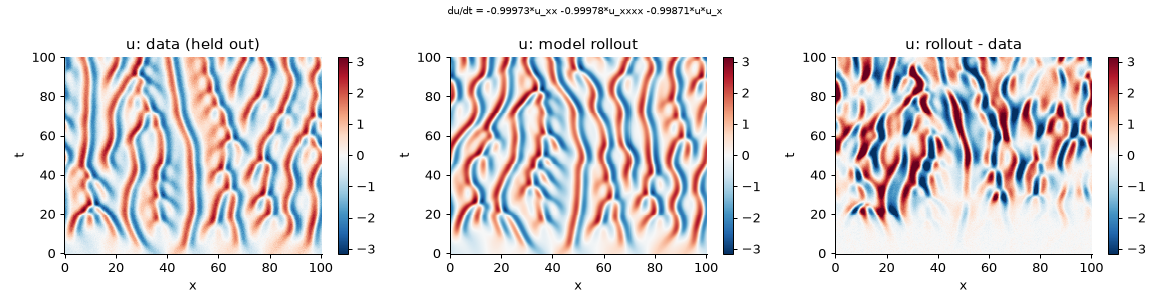

In [11]:
d, m_, d_, w_ = models["kuramoto_sivashinsky"]
plots.plot_model(m_, d_, w_["rhs"], "/tmp/_ksw.png"); display(Image("/tmp/_ksw.png"))